In [1]:
#TMDB Extract

In [2]:
from src.etl.extract import Extract

extractor = Extract()
data = extractor.fetch_movies()

len(data)
data[0]

Fetching pages: 25/25 | Movies: 500 | Time: 5.7s


{'adult': False,
 'backdrop_path': '/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg',
 'genre_ids': [10751, 35, 12, 14, 16],
 'id': 1226863,
 'original_language': 'en',
 'original_title': 'The Super Mario Galaxy Movie',
 'overview': "Having thwarted Bowser's previous plot to marry Princess Peach, Mario and Luigi now face a fresh threat in Bowser Jr., who is determined to liberate his father from captivity and restore the family legacy. Alongside companions new and old, the brothers travel across the stars to stop the young heir's crusade.",
 'popularity': 629.9843,
 'poster_path': '/eJGWx219ZcEMVQJhAgMiqo8tYY.jpg',
 'release_date': '2026-04-01',
 'title': 'The Super Mario Galaxy Movie',
 'video': False,
 'vote_average': 6.824,
 'vote_count': 446}

Basic Transform

In [3]:
from src.etl.transform import Transform

df = Transform.to_dataframe(data)

print(df.shape)
df.head()
df.describe()

Valid rows: 500
Invalid rows skipped: 0
(500, 9)


,movie_id,rating,popularity,release_year
count,5.000000e+02,500.000000,500.000000,500.000000
mean,3.495352e+05,6.807400,11.702251,2009.514000
std,4.264764e+05,1.161751,35.198269,15.831838
min,2.200000e+01,0.000000,2.235800,1938.000000
25%,1.007700e+04,6.300000,5.192000,2002.750000
50%,1.229115e+05,7.000000,6.563050,2013.000000
75%,5.599445e+05,7.500000,9.721575,2022.000000
max,1.575337e+06,8.500000,629.984300,2026.000000


In [4]:
df.isnull().sum()

movie_id        0
title           0
release_date    0
rating          0
popularity      0
genre_ids       0
genres          0
category        0
release_year    0
dtype: int64

<Axes: title={'center': 'Movies per Year'}, xlabel='release_year'>

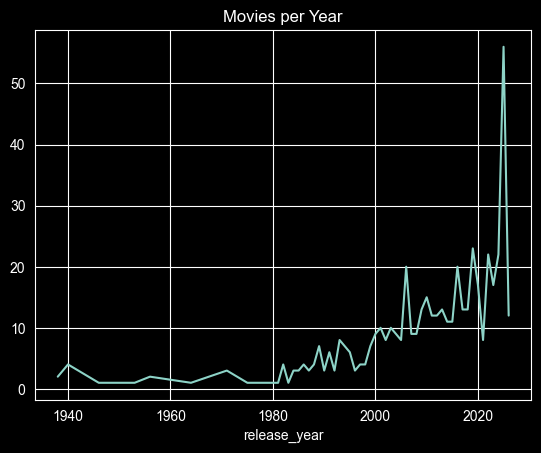

In [5]:
df.groupby("release_year").size().plot(title="Movies per Year")

In [6]:
df.sort_values(by="rating", ascending=False).head(10)[["title", "rating"]]

,title,rating
22,The Green Mile,8.5
19,Spirited Away,8.5
82,The Legend of Hei 2,8.5
69,The Legend of Hei 2,8.5
54,Cosmic Princess Kaguya!,8.5
399,A Dog's Will,8.4
29,Howl's Moving Castle,8.4
304,Light of the World,8.4
369,Light of the World,8.4
17,The Lord of the Rings: The Fellowship of the Ring,8.4


In [7]:
import os
from dotenv import load_dotenv
import duckdb
from src.utils.paths import project_path

load_dotenv()
DUCKDB_PATH_ENV = os.getenv("DUCKDB_PATH", "data/db/movies.duckdb")
DB_PATH = project_path(DUCKDB_PATH_ENV)
print("Resolved DuckDB path:", DB_PATH)

# Connect and query
with duckdb.connect(DB_PATH) as con:
    df_db = con.execute("SELECT * FROM movies").fetchdf()
    df_db.head()

Resolved DuckDB path: C:\Users\strom\code\Grupp7_Datavisualisering_DE_UX\data\db\movies.duckdb


##Upcoming movies

In [8]:
from datetime import datetime

today = datetime.today().date()

unreleased = df[df["release_date"] > today]
unreleased.head()

,movie_id,title,release_date,rating,popularity,genre_ids,genres,category,release_year
5,980431,"Avatar: Aang, The Last Airbender",2026-10-09,0.0,99.0487,"[28, 12, 16, 14, 10751]","Action, Adventure, Animation, Fantasy, Family",Fairy Tale,2026
74,931285,Mortal Kombat II,2026-05-06,0.0,12.3913,"[28, 14, 12]","Action, Fantasy, Adventure",Sword and Sorcery,2026
97,1108427,Moana,2026-07-08,0.0,12.0383,"[10751, 14, 35, 12]","Family, Fantasy, Comedy, Adventure",Fantasy Epic,2026
187,656908,Ramayana,2026-11-08,0.0,7.7583,"[18, 14, 28]","Drama, Fantasy, Action",Sword and Sorcery,2026
193,454639,Masters of the Universe,2026-06-03,0.0,7.6223,"[28, 14, 878]","Action, Fantasy, Sci-Fi",Sword and Sorcery,2026


Test case för top5 of movies

In [9]:
from src.etl.extract import Extract
from src.services.tmdb_service import TMDBService

extractor = Extract()
service = TMDBService()
movies = extractor.fetch_movies(pages=25)

# Only enrich top 5
for movie in movies[:10]:
    details = service.get_movie_details(movie["id"])
    print(details)

Fetching pages: 25/25 | Movies: 500 | Time: 5.6s
Cache hit for movie 1226863
movie_id=1226863 runtime=98 budget=110000000 revenue=628589780 overview="Having thwarted Bowser's previous plot to marry Princess Peach, Mario and Luigi now face a fresh threat in Bowser Jr., who is determined to liberate his father from captivity and restore the family legacy. Alongside companions new and old, the brothers travel across the stars to stop the young heir's crusade." director='Michael Jelenic' last_updated=Timestamp('2026-04-15 19:44:55.383765')
Cache hit for movie 83533
movie_id=83533 runtime=198 budget=350000000 revenue=1485988186 overview="In the wake of the devastating war against the RDA and the loss of their eldest son, Jake Sully and Neytiri face a new threat on Pandora: the Ash People, a violent and power-hungry Na'vi tribe led by the ruthless Varang. Jake's family must fight for their survival and the future of Pandora in a conflict that pushes them to their emotional and physical limit

In [10]:
from src.repository.movie_repository import MovieRepository

with MovieRepository(DB_PATH) as repo:
    print(repo.conn.execute("SHOW TABLES").fetchall())


[('genres',), ('movie_details',), ('movie_genres',), ('movies',)]
